# **Data Analysis**
**Andreas Heindl**

WS2025
## Solar Power Plant Data

In [41]:
# Import the necessary libraries
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import plotly.express as px


# 1. Choose Dataset
## Dataset Description

**Dataset name and source:**
- Name: solar-power-generation-data
- Source: anikanna from kagglehub



In [42]:
# Download Dataset
# Use kagglehub to download the latest version of the solar power Generation dataset.
path = kagglehub.dataset_download("anikannal/solar-power-generation-data")

# Print the path to dataset files
print("Path to dataset files:", path)

Path to dataset files: C:\Users\RandyAndy\.cache\kagglehub\datasets\anikannal\solar-power-generation-data\versions\1


In [43]:
# Load the first dataset into a pandas DataFrame
file_path_generation = os.path.join(path, "Plant_1_Generation_Data.csv")
generation_data_initial = pd.read_csv(file_path_generation)

file_path_weather = os.path.join(path, "Plant_1_Weather_Sensor_Data.csv")
weather_data_initial = pd.read_csv(file_path_weather)

# 2.1 A Data Preprocessing and Data Quality (70 points)

## Dataset overview (dimensions, columns, types, time range, sampling rate, missingness summary) (10 points)

In [44]:
def print_overview(df):
    # Dimenstions
    print('Shape:', df.shape)

    # Columns and data types
    print('\nColumns and data types:')
    print(df.dtypes)

    # Time range
    tmin = df['DATE_TIME'].min(); tmax = df['DATE_TIME'].max()
    print('\nTime range:', tmin, 'to', tmax)
    diffs = df['DATE_TIME'].drop_duplicates().diff().dropna()
    med = diffs.median()

    # Sampling rate
    print('Sampling median:', med)
    print('Sampling rate (minutes):', med.total_seconds() / 60)

    # Missingness summary
    missing_counts = df.isnull().sum()
    missing_percent = (missing_counts / len(df) * 100).round(2)
    overview_df = pd.DataFrame({
        'missing_count': missing_counts,
        'missing_percent': missing_percent,
    }).sort_values('missing_percent', ascending=False)
    print('\nMissingness summary:')
    display(overview_df.head(20))
    print('\n')

    # Missing timestamps
    df_sorted = df.sort_values('DATE_TIME')
    df_sorted['TIME_DIFF'] = df_sorted['DATE_TIME'].diff()
    expected_diff = med
    large_gaps = df_sorted[df_sorted['TIME_DIFF'] > expected_diff]
    print('Large time gaps (greater than expected sampling rate):')
    display(large_gaps[['DATE_TIME', 'TIME_DIFF']])
    print('\n')


# Had issue with datetime format, convert to a known format
generation_data_initial['DATE_TIME'] = pd.to_datetime(generation_data_initial['DATE_TIME'], format='%d-%m-%Y %H:%M', dayfirst=True)
# Convert weather DATE_TIME using the known format for this dataset
weather_data_initial['DATE_TIME'] = pd.to_datetime(weather_data_initial['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Run for both datasets
print("\nGeneration Data Overview:")
print_overview(generation_data_initial)

print("\nWeather Data Overview:")
print_overview(weather_data_initial)


Generation Data Overview:
Shape: (68778, 7)

Columns and data types:
DATE_TIME      datetime64[ns]
PLANT_ID                int64
SOURCE_KEY             object
DC_POWER              float64
AC_POWER              float64
DAILY_YIELD           float64
TOTAL_YIELD           float64
dtype: object

Time range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Sampling median: 0 days 00:15:00
Sampling rate (minutes): 15.0

Missingness summary:


,missing_count,missing_percent
DATE_TIME,0,0.0
PLANT_ID,0,0.0
SOURCE_KEY,0,0.0
DC_POWER,0,0.0
AC_POWER,0,0.0
DAILY_YIELD,0,0.0
TOTAL_YIELD,0,0.0




Large time gaps (greater than expected sampling rate):


,DATE_TIME,TIME_DIFF
1965,2020-05-16 02:00:00,0 days 03:00:00
9159,2020-05-19 12:30:00,0 days 01:00:00
11302,2020-05-20 17:30:00,0 days 04:15:00
11785,2020-05-21 07:45:00,0 days 09:00:00
15644,2020-05-23 06:45:00,0 days 01:45:00
16973,2020-05-23 22:00:00,0 days 00:30:00
19737,2020-05-25 06:00:00,0 days 00:30:00
27418,2020-05-29 06:15:00,0 days 08:00:00
67272,2020-06-17 06:45:00,0 days 00:45:00





Weather Data Overview:
Shape: (3182, 6)

Columns and data types:
DATE_TIME              datetime64[ns]
PLANT_ID                        int64
SOURCE_KEY                     object
AMBIENT_TEMPERATURE           float64
MODULE_TEMPERATURE            float64
IRRADIATION                   float64
dtype: object

Time range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Sampling median: 0 days 00:15:00
Sampling rate (minutes): 15.0

Missingness summary:


,missing_count,missing_percent
DATE_TIME,0,0.0
PLANT_ID,0,0.0
SOURCE_KEY,0,0.0
AMBIENT_TEMPERATURE,0,0.0
MODULE_TEMPERATURE,0,0.0
IRRADIATION,0,0.0




Large time gaps (greater than expected sampling rate):


,DATE_TIME,TIME_DIFF
93,2020-05-16 02:00:00,0 days 03:00:00
420,2020-05-19 12:30:00,0 days 01:00:00
520,2020-05-20 17:30:00,0 days 04:15:00
549,2020-05-21 07:45:00,0 days 07:15:00
732,2020-05-23 06:45:00,0 days 01:30:00
792,2020-05-23 22:00:00,0 days 00:30:00
1288,2020-05-29 06:15:00,0 days 04:30:00
1799,2020-06-03 14:15:00,0 days 00:30:00


## Basic statistical analysis using pandas (descriptives, grouped stats, quantiles) (10 points)

In [45]:
print("Generation Data grouped stats and quantiles:")
describe = generation_data_initial[['AC_POWER', 'DC_POWER', 'TOTAL_YIELD', 'DAILY_YIELD']].describe(percentiles=[0.25, 0.5, 0.75])
display(describe)

print("\nWeather Data grouped stats and quantiles:")
describe_weather = weather_data_initial[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']].describe(percentiles=[0.25, 0.5, 0.75])
display(describe_weather)

# Grouped stats of inverter/source keys
print("\nGeneration Data grouped stats by SOURCE_KEY:")
grouped_generation = generation_data_initial.groupby('SOURCE_KEY')[['AC_POWER', 'DC_POWER', 'TOTAL_YIELD', 'DAILY_YIELD']].agg(['mean', 'median', 'std', 'min', 'max'])
display(grouped_generation) 

# Time based hourly patterns
generation_data_initial['HOUR'] = generation_data_initial['DATE_TIME'].dt.hour
hourly_stats = generation_data_initial.groupby('HOUR')[['AC_POWER', 'DC_POWER']].mean()
print("\nHourly average AC_POWER and DC_POWER:")
display(hourly_stats)

Generation Data grouped stats and quantiles:


,AC_POWER,DC_POWER,TOTAL_YIELD,DAILY_YIELD
count,68778.000000,68778.000000,6.877800e+04,68778.000000
mean,307.802752,3147.426211,6.978712e+06,3295.968737
std,394.396439,4036.457169,4.162720e+05,3145.178309
min,0.000000,0.000000,6.183645e+06,0.000000
25%,0.000000,0.000000,6.512003e+06,0.000000
50%,41.493750,429.000000,7.146685e+06,2658.714286
75%,623.618750,6366.964286,7.268706e+06,6274.000000
max,1410.950000,14471.125000,7.846821e+06,9163.000000



Weather Data grouped stats and quantiles:


,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE
count,3182.000000,3182.000000,3182.000000
mean,0.228313,25.531606,31.091015
std,0.300836,3.354856,12.261222
min,0.000000,20.398505,18.140415
25%,0.000000,22.705182,21.090553
50%,0.024653,24.613814,24.618060
75%,0.449588,27.920532,41.307840
max,1.221652,35.252486,65.545714



Generation Data grouped stats by SOURCE_KEY:


AC_POWER                                           \
                       mean     median         std  min          max   
SOURCE_KEY                                                             
1BY6WEcLGh8j5v7  281.124073  29.261607  367.646871  0.0  1300.171429   
1IF53ai7Xc0U56Y  315.488026  43.687500  402.301747  0.0  1394.514286   
3PZuoBAID5Wc2HD  314.967354  44.123214  402.373790  0.0  1399.225000   
7JYdWkrLSPkdwr4  306.385671  42.428571  392.300240  0.0  1384.871429   
McdE0feGgRqW7Ca  314.046321  42.502679  402.278537  0.0  1405.800000   
VHMLBKoKgIrUVDU  313.900096  43.214286  402.009046  0.0  1394.214286   
WRmjgnKYAwPKWDb  308.575465  43.457143  393.673488  0.0  1376.350000   
YxYtjZvoooNbGkE  310.930334  46.478571  395.711539  0.0  1410.528571   
ZnxXDlPa8U1GXgE  312.346427  42.379464  399.791497  0.0  1391.642857   
ZoEaEvLYb1n2sOq  306.980623  43.600000  391.891363  0.0  1395.485714   
adLQvlD726eNBSB  319.693862  45.400000  407.920560  0.0  1405.585714   
bvBOhCH3iADSZry  276.778938  27.514286  361.579929  0.0  1265.157143   
iCRJl6heRkivqQ3  312.540320  42.742857  399.354809  0.0  1407.542857   
ih0vzX44oOqAx2f  302.962438  41.450000  388.040381  0.0  1377.314286   
pkci93gMrogZuBj  309.670213  42.528571  394.942694  0.0  1379.625000   
rGa61gmuvPhdLxV  309.345658  43.106250  394.750370  0.0  1392.842857   
sjndEbLyjtCKgGv  307.912265  41.750000  393.687601  0.0  1399.842857   
uHbuxQJl8lW7ozc  312.467844  43.385714  398.359247  0.0  1377.250000   
wCURE6d3bPkepu2  310.064044  41.916071  398.780301  0.0  1410.950000   
z9Y9gH1T5YWrNuG  306.492026  40.021429  393.570990  0.0  1401.125000   
zBIq5rxdHJRwDNY  307.925344  42.685714  393.246025  0.0  1393.242857   
zVJPv84UY57bAof  311.676665  42.550000  398.685362  0.0  1397.085714   

                    DC_POWER                                             \
                        mean      median          std  min          max   
SOURCE_KEY                                                                
1BY6WEcLGh8j5v7  2873.720981  302.955357  3761.145773  0.0  13335.14286   
1IF53ai7Xc0U56Y  3226.336768  451.625000  4117.942833  0.0  14302.71429   
3PZuoBAID5Wc2HD  3221.015673  456.160714  4118.576051  0.0  14351.12500   
7JYdWkrLSPkdwr4  3132.891955  438.571429  4014.963827  0.0  14204.00000   
McdE0feGgRqW7Ca  3211.307245  439.571429  4117.113844  0.0  14418.42857   
VHMLBKoKgIrUVDU  3210.102563  446.714286  4114.886897  0.0  14299.85714   
WRmjgnKYAwPKWDb  3155.384433  449.428571  4029.070312  0.0  14116.25000   
YxYtjZvoooNbGkE  3179.492570  480.642857  4050.058516  0.0  14466.85714   
ZnxXDlPa8U1GXgE  3194.059104  438.258929  4092.017013  0.0  14273.28571   
ZoEaEvLYb1n2sOq  3139.009808  451.000000  4010.701129  0.0  14312.71429   
adLQvlD726eNBSB  3269.567669  469.857143  4175.815364  0.0  14416.14286   
bvBOhCH3iADSZry  2828.998291  285.000000  3698.531647  0.0  12976.00000   
iCRJl6heRkivqQ3  3196.074675  442.285714  4087.526979  0.0  14436.28571   
ih0vzX44oOqAx2f  3097.714161  428.571429  3971.122441  0.0  14126.42857   
pkci93gMrogZuBj  3166.599439  439.714286  4042.101194  0.0  14149.87500   
rGa61gmuvPhdLxV  3163.240929  445.830357  4040.112422  0.0  14285.71429   
sjndEbLyjtCKgGv  3148.270450  431.750000  4028.665755  0.0  14357.42857   
uHbuxQJl8lW7ozc  3195.316080  448.571429  4077.234652  0.0  14125.62500   
wCURE6d3bPkepu2  3170.704424  433.446429  4081.628327  0.0  14471.12500   
z9Y9gH1T5YWrNuG  3134.037738  414.000000  4028.058883  0.0  14370.50000   
zBIq5rxdHJRwDNY  3148.590013  441.428571  4024.500149  0.0  14289.57143   
zVJPv84UY57bAof  3187.236622  440.125000  4080.647086  0.0  14329.14286   

                  TOTAL_YIELD                                         \
                         mean        median           std        min   
SOURCE_KEY                                                             
1BY6WEcLGh8j5v7  6.377464e+06  6.381896e+06  66899.659902  6259559.0   
1IF53ai7Xc0U56Y  6.313086e+06  6.317141e+06  73427.330


Hourly average AC_POWER and DC_POWER:


,AC_POWER,DC_POWER
HOUR,,
0,0.000000,0.000000
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000000,0.000000
4,0.000000,0.000000
5,0.000000,0.000000
6,56.135778,578.113622
7,250.239163,2551.386720
8,498.911000,5088.628218


## Original data quality analysis with visualization (missingness patterns, outliers, duplicates, timestamp gaps, inconsistent units) (20 points)


Can see wrong AC power (factor 10)


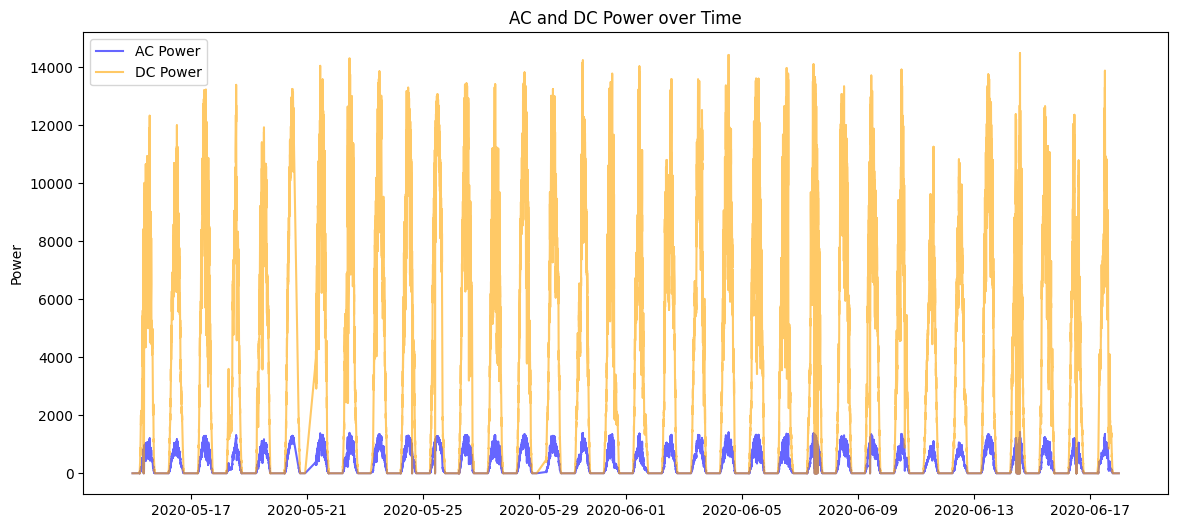


Other generation data columns


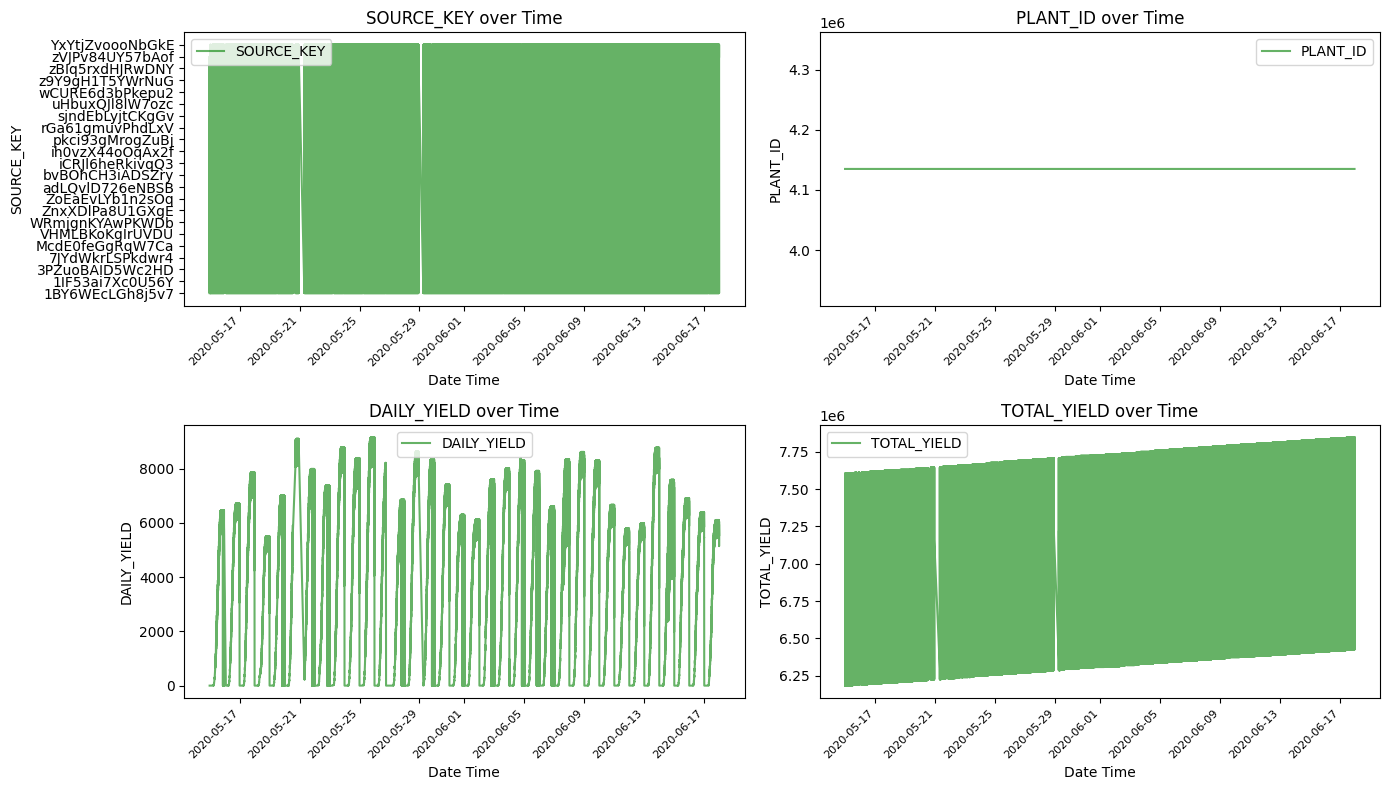


Remove Plant ID and Source Key


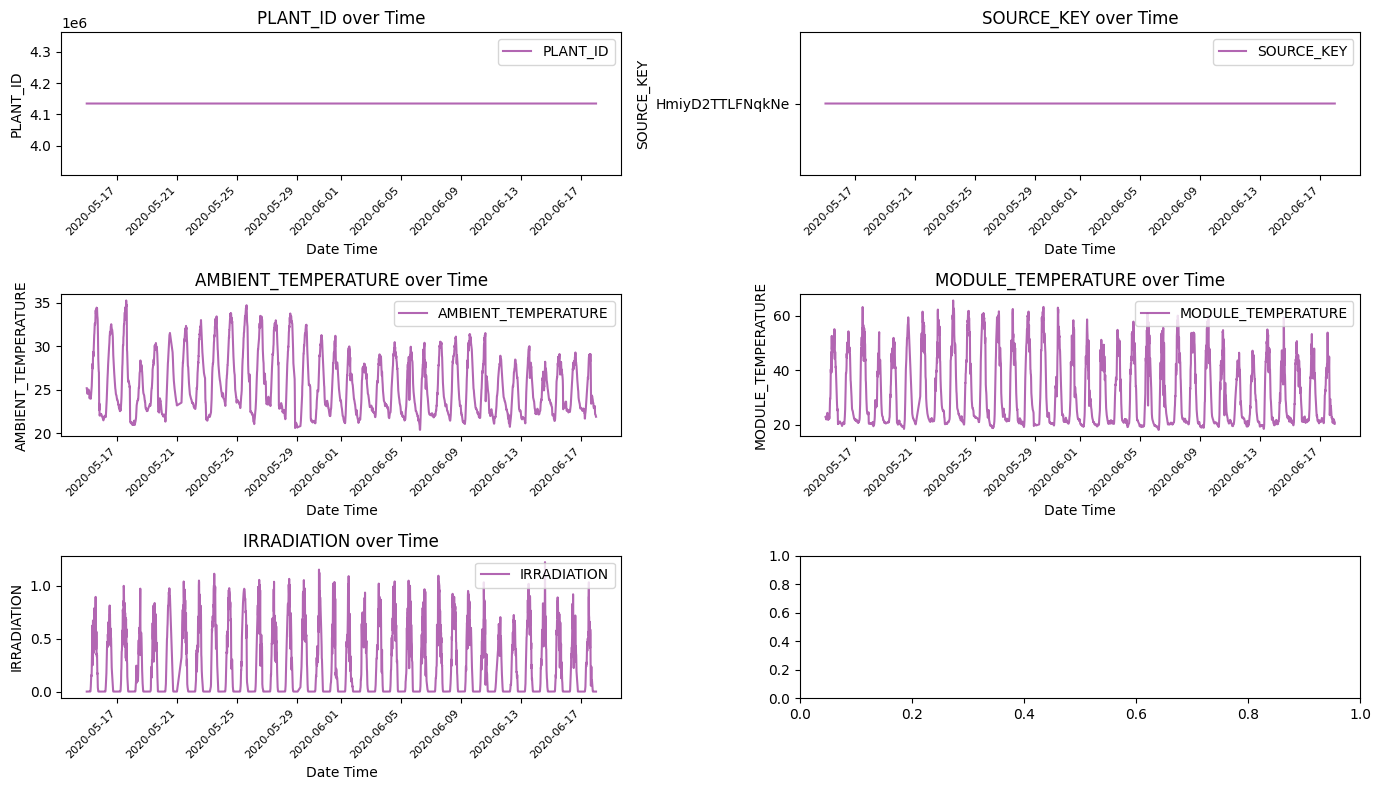


Remove Plant ID and Source Key

Can also remove Total Yield as it only is for different source keys.

Total Yield per Source Key over Time


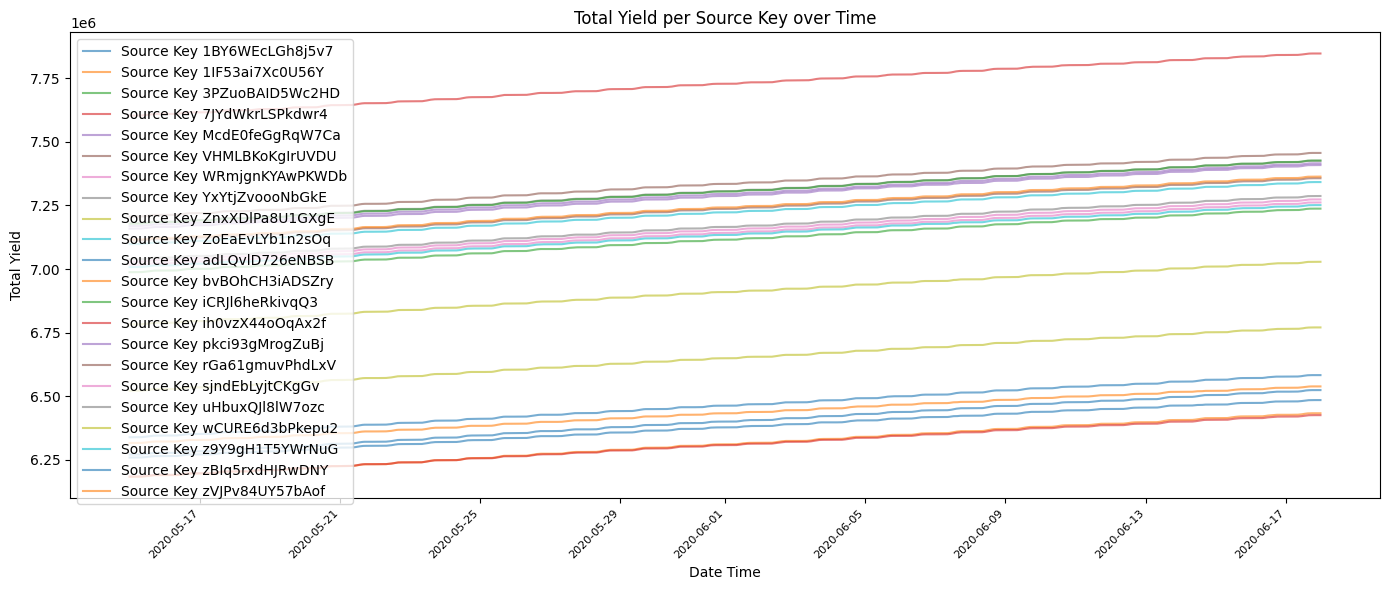


Total Yield and Daily Yield for Source Key 1BY6WEcLGh8j5v7


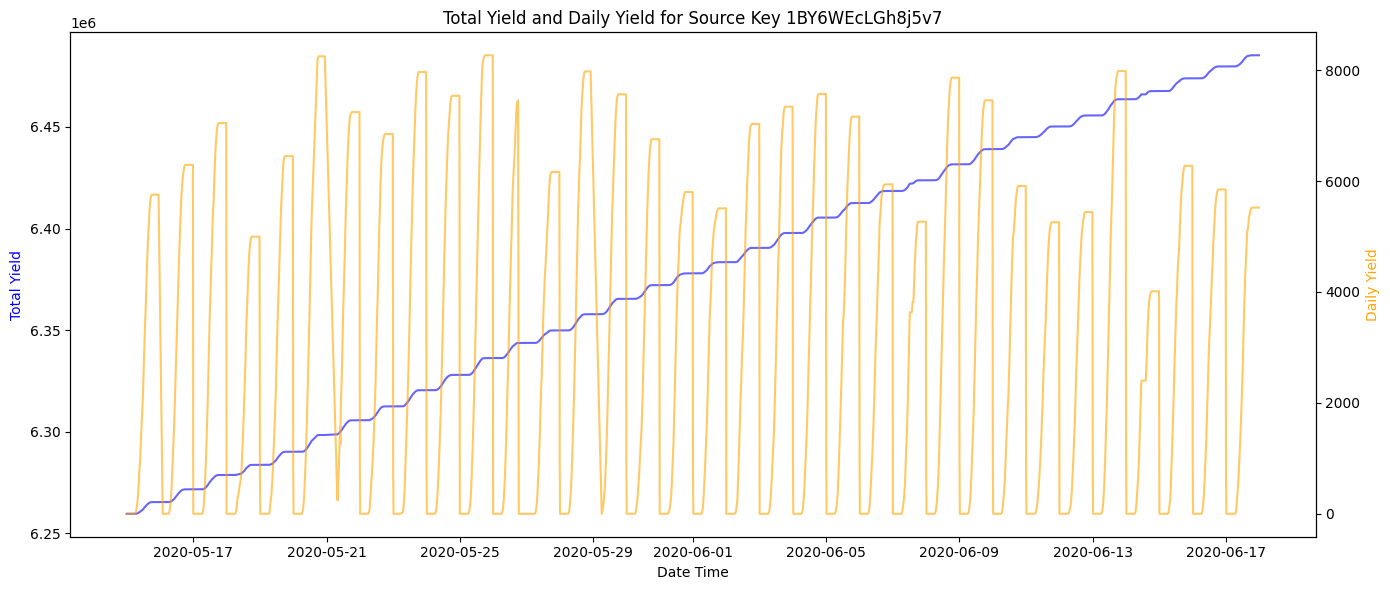

In [46]:
# Visualize ac and dc power over time with a zoomed subplot
print("\nCan see wrong AC power (factor 10)")
# Top plot - full series
plt.plot(generation_data_initial['DATE_TIME'], generation_data_initial['AC_POWER'], label='AC Power', color='blue', alpha=0.6)
plt.plot(generation_data_initial['DATE_TIME'], generation_data_initial['DC_POWER'], label='DC Power', color='orange', alpha=0.6)
plt.ylabel('Power')
plt.title('AC and DC Power over Time')
plt.legend()
# change size of plot make it over the whole width
plt.gcf().set_size_inches(14, 6)
plt.show()

# plot all other columns
print("\nOther generation data columns")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
other_columns = ['SOURCE_KEY', 'PLANT_ID', 'DAILY_YIELD', 'TOTAL_YIELD']
for ax, column in zip(axes.flatten(), other_columns):
    ax.plot(generation_data_initial['DATE_TIME'], generation_data_initial[column], label=column, color='green', alpha=0.6)
    ax.set_xlabel('Date Time')
    ax.set_ylabel(column)
    ax.set_title(f'{column} over Time')
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()
print("\nRemove Plant ID and Source Key")

# Visually inspecting weather data
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 8))
weather_columns = ['PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
for ax, column in zip(axes.flatten(), weather_columns):
    ax.plot(weather_data_initial['DATE_TIME'], weather_data_initial[column], label=column, color='purple', alpha=0.6)
    ax.set_xlabel('Date Time')
    ax.set_ylabel(column)
    ax.set_title(f'{column} over Time')
    ax.legend()
    # Rotate x-axis date labels to avoid overlap and reduce font size
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()
print("\nRemove Plant ID and Source Key")
print("\nCan also remove Total Yield as it only is for different source keys.")

# Further inspection if total yield makes sense
print("\nTotal Yield per Source Key over Time")
plt.figure(figsize=(14, 6))
for source_key, group in generation_data_initial.groupby('SOURCE_KEY'):
    plt.plot(group['DATE_TIME'], group['TOTAL_YIELD'], label=f'Source Key {source_key}', alpha=0.6)
plt.xlabel('Date Time')
plt.ylabel('Total Yield')
plt.title('Total Yield per Source Key over Time')
plt.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# And plot the total yield of one source key and in the same one the daily yield to see if they correlate make 2 y axis because different scales
# And any random source key 1BY6WEcLGh8j5v7
print("\nTotal Yield and Daily Yield for Source Key 1BY6WEcLGh8j5v7")
source_key = '1BY6WEcLGh8j5v7'
subset = generation_data_initial[generation_data_initial['SOURCE_KEY'] == source_key]
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(subset['DATE_TIME'], subset['TOTAL_YIELD'], label='Total Yield', color='blue', alpha=0.6)
ax1.set_xlabel('Date Time')
ax1.set_ylabel('Total Yield', color='blue')
ax2 = ax1.twinx()
ax2.plot(subset['DATE_TIME'], subset['DAILY_YIELD'], label='Daily Yield', color='orange', alpha=0.6)
ax2.set_ylabel('Daily Yield', color='orange')
plt.title(f'Total Yield and Daily Yield for Source Key {source_key}')
fig.tight_layout()
plt.show()

# After visually inspecting for outliers i couldn't find any

## Data preprocessing pipeline (cleaning steps, handling missing data, outliers strategy, resampling or alignment if needed, feature engineering basics) (20 points)

In [ ]:
# Found some incosistent units in the generation data and going to fix that:
# Units of AC power does not match DC power at factor 10
generation_data_fix = generation_data_initial.copy()
generation_data_fix['AC_POWER'] = generation_data_initial['AC_POWER'] * 10

# We can remove the plant id column as it is always the same for both datasets
generation_data_fix = generation_data_fix.drop(columns=['PLANT_ID'])
weather_data_initial = weather_data_initial.drop(columns=['PLANT_ID'])

# IQR method for outlier detection for the generation data per source key
generation_data_clean = generation_data_fix.copy()
cols_to_clean_generation = ['DC_POWER', 'AC_POWER']

for col in cols_to_clean_generation:
    # Q1 and Q3 per SOURCE_KEY
    q1_per_group = generation_data_clean.groupby('SOURCE_KEY')[col].quantile(0.25)
    q3_per_group = generation_data_clean.groupby('SOURCE_KEY')[col].quantile(0.75)

    # map group quantiles back to rows
    q1_per_row = generation_data_clean['SOURCE_KEY'].map(q1_per_group)
    q3_per_row = generation_data_clean['SOURCE_KEY'].map(q3_per_group)

    # compute IQR and bounds per row
    iqr_per_row = q3_per_row - q1_per_row
    lower_bound = q1_per_row - 1.5 * iqr_per_row
    upper_bound = q3_per_row + 1.5 * iqr_per_row

    # identify outliers and replace with NaN
    before_nulls = generation_data_clean[col].isna().sum()
    invalid_mask = ~((generation_data_clean[col] >= lower_bound) & (generation_data_clean[col] <= upper_bound))
    removed_count = invalid_mask.sum()
    generation_data_clean.loc[invalid_mask, col] = np.nan
    after_nulls = generation_data_clean[col].isna().sum()

    print(f"{col}: removed {removed_count} values (nulls before={before_nulls}, after={after_nulls})")

# IQR method for outlier detection for the weather data
weather_data_clean = weather_data_initial.copy()
cols_to_clean_weather = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']

for col in cols_to_clean_weather:
    # Q1 and Q3
    q1 = weather_data_clean[col].quantile(0.25)
    q3 = weather_data_clean[col].quantile(0.75)

    # compute IQR and bounds
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # identify outliers and replace with NaN
    before_nulls = weather_data_clean[col].isna().sum()
    invalid_mask = ~((weather_data_clean[col] >= lower_bound) & (weather_data_clean[col] <= upper_bound))
    removed_count = invalid_mask.sum()
    weather_data_clean.loc[invalid_mask, col] = np.nan
    after_nulls = weather_data_clean[col].isna().sum()

    print(f"{col}: removed {removed_count} values (nulls before={before_nulls}, after={after_nulls})")


# Merge datasets on DATE_TIME - pivot per inverter (SOURCE_KEY) then merge
# Pivot generation data so each SOURCE_KEY becomes columns for DC/AC/daily yield
generation_dc_power = pd.pivot_table(generation_data_clean, index='DATE_TIME', columns='SOURCE_KEY', values='DC_POWER').reset_index()
generation_ac_power = pd.pivot_table(generation_data_clean, index='DATE_TIME', columns='SOURCE_KEY', values='AC_POWER').reset_index()
generation_total_yield = pd.pivot_table(generation_data_clean, index='DATE_TIME', columns='SOURCE_KEY', values='TOTAL_YIELD').reset_index()
generation_daily_yield = pd.pivot_table(generation_data_clean, index='DATE_TIME', columns='SOURCE_KEY', values='DAILY_YIELD').reset_index()

# Rename daily yield columns to indicate they are per-inverter daily values
generation_total_yield.columns = ['DATE_TIME'] + [f"{col}_total" for col in generation_total_yield.columns if col != 'DATE_TIME']
generation_daily_yield.columns = ['DATE_TIME'] + [f"{col}_daily" for col in generation_daily_yield.columns if col != 'DATE_TIME']

# Merge the pivot tables sequentially and then merge weather (left-join generation -> keep generation timestamps)
df_merged = pd.merge(generation_dc_power, generation_ac_power, on='DATE_TIME', suffixes=('_dc', '_ac'))
df_merged = pd.merge(df_merged, generation_total_yield, on='DATE_TIME')
df_merged = pd.merge(df_merged, generation_daily_yield, on='DATE_TIME')
df_merged = pd.merge(df_merged, weather_data_initial, on='DATE_TIME', how='left')

# Drop source key from merged dataframe (assuming weather data is representative for whole plant)
col = 'SOURCE_KEY'
if col in df_merged.columns:
    df_merged = df_merged.drop(columns=[col])

# Again checking missingness on merged data
print('Missing data in merged data:')
print(df_merged.isnull().sum())

# Do another short describe of merged data
print("\nMerged Data Overview:")
describe_merged = df_merged.describe(percentiles=[0.25, 0.5, 0.75])
display(describe_merged)

# remove long missing runs (>6)
exclude = ['DATE_TIME','IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE']
indices_to_remove = set()

for column_name in df_merged.columns:
    if column_name in exclude:
        continue
    missing_mask = df_merged[column_name].isna()
    if not missing_mask.any():
        continue
    # create group ids for consecutive runs
    group_id = (missing_mask != missing_mask.shift()).cumsum()
    # compute run lengths per group id
    run_lengths = missing_mask.groupby(group_id).sum()
    # select groups threshold length (6)
    long_run_groups = run_lengths[run_lengths > 6].index
    for group in long_run_groups:
        rows_in_group = df_merged.index[group_id == group].tolist()
        indices_to_remove.update(rows_in_group)

rows_to_remove = sorted(indices_to_remove)
print(f"Removing {len(rows_to_remove)} rows with long missing sequences")
df_shortened = df_merged.drop(index=rows_to_remove).reset_index(drop=True)

# time-based interpolation per inverter column
df_to_interpolate = df_shortened.set_index('DATE_TIME').sort_index()
inverter_columns = [col for col in df_to_interpolate.columns if col.endswith('_dc') or col.endswith('_ac') or col.endswith('_daily')]

for inverter_col in inverter_columns:
    na_before = df_to_interpolate[inverter_col].isna().sum()
    filled_series = df_to_interpolate[inverter_col].interpolate(method='time', limit=4, limit_direction='both')
    newly_filled_count = int(((df_to_interpolate[inverter_col].isna()) & (filled_series.notna())).sum())
    df_to_interpolate[inverter_col] = filled_series
    print(f"{inverter_col}: filled {newly_filled_count} (na before={na_before}, na after={df_to_interpolate[inverter_col].isna().sum()})")

df_interpolated = df_to_interpolate.reset_index()

print("\nAfter Interpolation - Merged Data Overview:")
print('Missing data in interpolated merged data:')
print(df_interpolated.isnull().sum())

# There exactly one missing value for irradiation, ambient temperature and module temperature now do a interpolation again
# Very simple interpolation for these 3 columns
# Ensure we have a DatetimeIndex for time-based interpolation
df_interpolated = df_interpolated.set_index('DATE_TIME').sort_index()

for col in ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']:
    na_before = df_interpolated[col].isna().sum()
    df_interpolated[col] = df_interpolated[col].interpolate(method='time', limit=2, limit_direction='both')
    na_after = df_interpolated[col].isna().sum()
    filled_count = na_before - na_after
    print(f"{col}: filled {filled_count} (na before={na_before}, na after={na_after})")

# restore DATE_TIME as a column
df_interpolated = df_interpolated.reset_index()

# And now last thing: sum the values of the inverters so that we have a single value for each time period
df_summed = df_merged.copy()
df_summed['Total_DC'] = df_summed.filter(like='_dc').sum(axis=1)
df_summed['Total_AC'] = df_summed.filter(like='_ac').sum(axis=1)
df_summed['Total_Daily_Yield'] = df_summed.filter(like='_daily').sum(axis=1)
df_summed['Total_Yield'] = df_summed.filter(like='_total').sum(axis=1)
# Ensure required columns are present
required_columns = ['DATE_TIME', 'Total_DC', 'Total_AC', 'Total_Daily_Yield', 'Total_Yield', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
for col in required_columns:
    if col not in df_summed.columns:
        df_summed[col] = None
df_cummed = df_summed[required_columns]

print("\nSummed Data Overview:")
print('Missing data in summed data:')
print(df_cummed.isnull().sum())

DC_POWER: removed 0 values (nulls before=0, after=0)
AC_POWER: removed 0 values (nulls before=0, after=0)
IRRADIATION: removed 2 values (nulls before=0, after=2)
AMBIENT_TEMPERATURE: removed 0 values (nulls before=0, after=0)
MODULE_TEMPERATURE: removed 0 values (nulls before=0, after=0)
Missing data in merged data:
DATE_TIME                 0
1BY6WEcLGh8j5v7_dc        4
1IF53ai7Xc0U56Y_dc       39
3PZuoBAID5Wc2HD_dc       40
7JYdWkrLSPkdwr4_dc       25
                         ..
zBIq5rxdHJRwDNY_daily    39
zVJPv84UY57bAof_daily    34
AMBIENT_TEMPERATURE       1
MODULE_TEMPERATURE        1
IRRADIATION               1
Length: 92, dtype: int64

Merged Data Overview:


,DATE_TIME,1BY6WEcLGh8j5v7_dc,1IF53ai7Xc0U56Y_dc,3PZuoBAID5Wc2HD_dc,7JYdWkrLSPkdwr4_dc,McdE0feGgRqW7Ca_dc,VHMLBKoKgIrUVDU_dc,WRmjgnKYAwPKWDb_dc,YxYtjZvoooNbGkE_dc,ZnxXDlPa8U1GXgE_dc,...,rGa61gmuvPhdLxV_daily,sjndEbLyjtCKgGv_daily,uHbuxQJl8lW7ozc_daily,wCURE6d3bPkepu2_daily,z9Y9gH1T5YWrNuG_daily,zBIq5rxdHJRwDNY_daily,zVJPv84UY57bAof_daily,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3158,3154.000000,3119.000000,3118.000000,3133.000000,3124.000000,3133.000000,3118.000000,3104.000000,3130.000000,...,3124.000000,3124.000000,3125.000000,3126.000000,3126.000000,3119.000000,3124.000000,3157.000000,3157.000000,3157.000000
mean,2020-06-01 06:42:44.344521728,2873.720981,3226.336768,3221.015673,3132.891955,3211.307245,3210.102563,3155.384433,3179.492570,3194.059104,...,3272.289839,3245.007129,3311.003159,3256.768423,3260.837944,3231.159950,3297.805678,25.560257,31.175453,0.230103
min,2020-05-15 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.398505,18.140415,0.000000
25%,2020-05-23 23:18:45,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.739895,21.130249,0.000000
50%,2020-06-01 12:37:30,302.955357,451.625000,456.160714,438.571429,439.571429,446.714286,449.428571,480.642857,438.258929,...,2557.937500,2568.696428,2582.571429,2557.982143,2557.642857,2439.428571,2557.151786,24.680324,24.801971,0.027748
75%,2020-06-09 17:56:15,5775.531250,6494.571428,6503.294643,6309.000000,6506.245536,6461.571429,6347.937500,6408.562500,6463.468750,...,6243.000000,6255.000000,6292.000000,6274.000000,6300.000000,6283.142857,6262.000000,27.941221,41.449481,0.451576
max,2020-06-17 23:45:00,13335.142860,14302.714290,14351.125000,14204.000000,14418.428570,14299.857140,14116.250000,14466.857140,14273.285710,...,8821.000000,8777.000000,8913.000000,8895.000000,8802.000000,8891.000000,8842.000000,35.252486,65.545714,1.221652
std,NaN,3761.145773,4117.942833,4118.576051,4014.963827,4117.113844,4114.886897,4029.070312,4050.058516,4092.017013,...,3152.325389,3123.727650,3188.211692,3140.439073,3112.724797,3135.249481,3177.981805,3.351059,12.272685,0.301348


Removing 47 rows with long missing sequences
1BY6WEcLGh8j5v7_dc: filled 4 (na before=4, na after=0)
1IF53ai7Xc0U56Y_dc: filled 8 (na before=8, na after=0)
3PZuoBAID5Wc2HD_dc: filled 9 (na before=9, na after=0)
7JYdWkrLSPkdwr4_dc: filled 9 (na before=9, na after=0)
McdE0feGgRqW7Ca_dc: filled 27 (na before=27, na after=0)
VHMLBKoKgIrUVDU_dc: filled 9 (na before=9, na after=0)
WRmjgnKYAwPKWDb_dc: filled 9 (na before=9, na after=0)
YxYtjZvoooNbGkE_dc: filled 38 (na before=38, na after=0)
ZnxXDlPa8U1GXgE_dc: filled 11 (na before=11, na after=0)
ZoEaEvLYb1n2sOq_dc: filled 28 (na before=28, na after=0)
adLQvlD726eNBSB_dc: filled 8 (na before=8, na after=0)
bvBOhCH3iADSZry_dc: filled 3 (na before=3, na after=0)
iCRJl6heRkivqQ3_dc: filled 26 (na before=26, na after=0)
ih0vzX44oOqAx2f_dc: filled 11 (na before=11, na after=0)
pkci93gMrogZuBj_dc: filled 26 (na before=26, na after=0)
rGa61gmuvPhdLxV_dc: filled 27 (na before=27, na after=0)
sjndEbLyjtCKgGv_dc: filled 27 (na before=27, na after=0)
uH

## Preprocessed vs original comparison (before/after visuals plus commentary on what changed and why) (10 points)

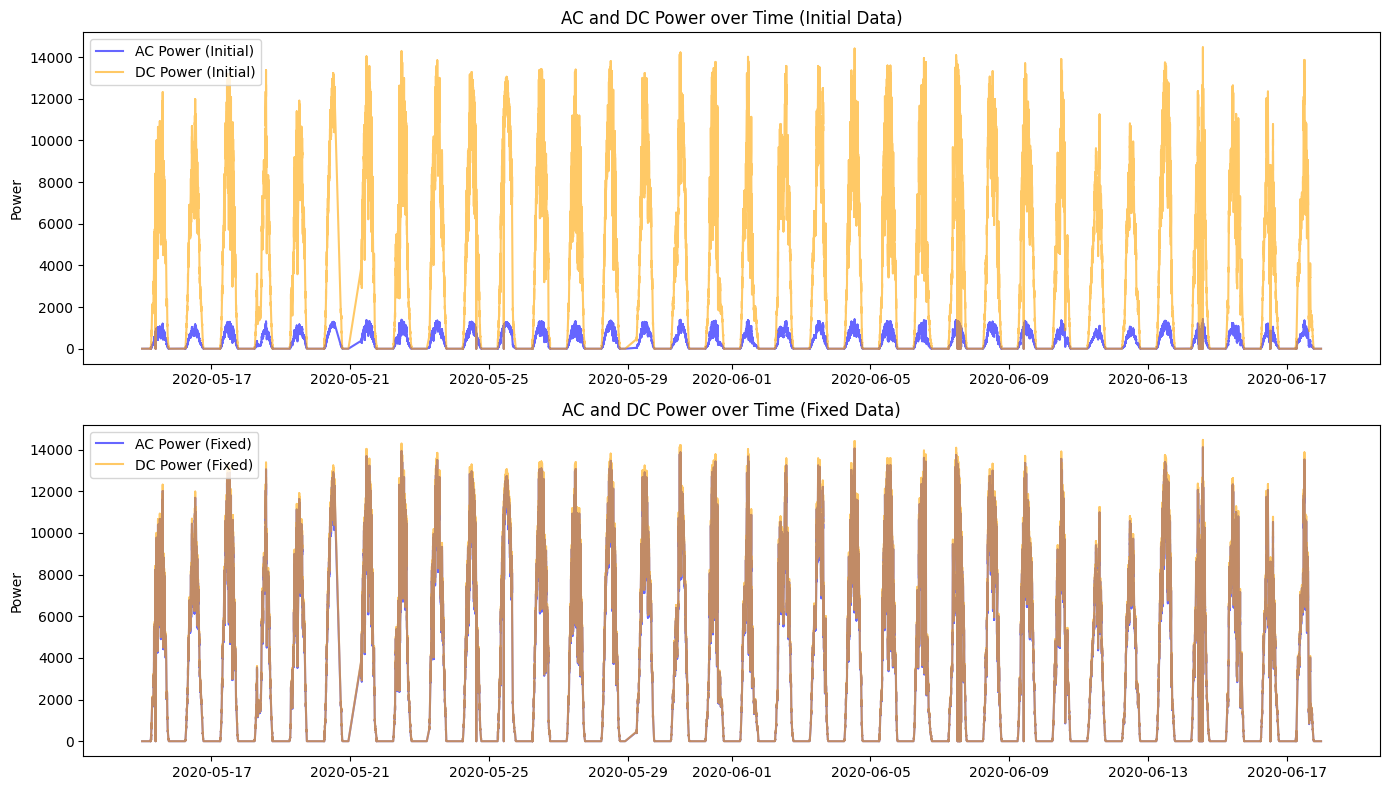

In [48]:
# Preprocessed vs original comparison (before/after visuals plus commentary on what changed and why) (10 points)

# What changed and why: ac power calculation fixed to match dc power scale
# Removed Plant ID columns as they were redundant and all data has the same plant ID - nothing to show visually
# I did not pivot the weather data as it would create too many NaN values, so I kept them as is and removed the source key column.
# Therefor I assume the weather data is representative for the whole plant


# At first plot initial ac/dc power
tmin = generation_data_initial['DATE_TIME'].min()
tmax = generation_data_initial['DATE_TIME'].max()
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 8))

# Top plot - full series
axes[0].plot(generation_data_initial['DATE_TIME'], generation_data_initial['AC_POWER'], label='AC Power (Initial)', color='blue', alpha=0.6)
axes[0].plot(generation_data_initial['DATE_TIME'], generation_data_initial['DC_POWER'], label='DC Power (Initial)', color='orange', alpha=0.6)
axes[0].set_ylabel('Power')
axes[0].set_title('AC and DC Power over Time (Initial Data)')
axes[0].legend()

# Bottom plot - scale fixed generation_data_fix
axes[1].plot(generation_data_fix['DATE_TIME'], generation_data_fix['AC_POWER'], label='AC Power (Fixed)', color='blue', alpha=0.6)
axes[1].plot(generation_data_fix['DATE_TIME'], generation_data_fix['DC_POWER'], label='DC Power (Fixed)', color='orange', alpha=0.6)
axes[1].set_ylabel('Power')
axes[1].set_title('AC and DC Power over Time (Fixed Data)')
axes[1].legend()
plt.tight_layout()
plt.show()


# I really don't like making up measured values but for the sake of analysis I did a conservative interpolation so visualization and some regression models can be run
# Plot0

# 2.2 B. Visualization and Exploratory Data Analysis (55 points)

## Time-series visualizations (raw, smoothed, rolling mean or windowed views) (10 points)

## Distribution analysis with histograms and density style plots where applicable (10 points)

## Daily or periodic pattern analysis (day-of-week, hour-of-day, seasonality indicators, or test-cycle patterns) (15 points)

## Correlation analysis and heatmaps (Pearson and at least one alternative such as Spearman, with short interpretation) (10 points)

# 2.3 C. Probability and Event Analysis (45 points)

## Threshold-based probability estimation for events (define event, justify threshold, compute empirical probability) (15 points)

## Cross tabulation analysis for two variables (10 points)

## Conditional probability analysis (at least two meaningful conditional relationships) (15points)

## Summary of observations and limitations (what could bias these estimates, what assumptions were made) (5 points)

# 2.4 D. Statistical Theory Application (30 points)

## Law of Large Numbers demonstration (15 points)

## Central Limit Theorem application (sampling distributions, effect of sample size, interpretation) (25 points)

## Result interpretation and sanity checks (what would invalidate your conclusion, what you verified) (5 points)

# 2.5 E. Regression and Predictive Modeling (45 points)

## Define a prediction target and features (justify why they make sense) (10 points)

## Linear or polynomial model selection (include rationale and show at least two candidates) (10 points)

## Model fitting and validation (train-test split appropriate for time-series. e.g., time-basedsplit) (15 points)

## Residual analysis and interpretation (errors, bias, failure cases, what to improve next) (10 points)

# 2.6 F. Dimensionality Reduction and Statistical Tests (40 points)

## **Part 1. Dimensionality Reduction (25 points)**

## PCA projection and interpretation (variance explained, what clusters or separations mean) (10 points)

## t-SNE embedding with justified hyperparameters (perplexity or similar) and interpretation (7 points)

## UMAP embedding with justified hyperparameters (neighbors, min dist or similar) and interpretation (8 points)

## **Part 2. Hypothesis Tests (15 points)**

## Perform at least three tests. Each test must include: null hypothesis, why the test is appropriate, assumptions, p-value, and practical interpretation.

### Chi-square test (choose one) (5 points):
- Chi-square test of independence (use a contingency table from two categorical or binned variables), or
- Chi-square goodness-of-fit (compare observed counts to an expected distribution you justify).


### One mean or location comparison test (choose one) (5 points):
- t-test
- Welch t-test
- Mann-Whitney U
- ANOVA

### One time-series relevant test (choose one) (5 points):
- stationarity test (ADF or KPSS)
- Ljung-Box for autocorrelation
- change-point style test if justified